In [6]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [7]:
from boulder_statistics.analysis.power_law_var_g_fitting import PowerLawVarGFitting
from boulder_statistics.analysis.sensitivity_model.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = PowerLawVarGFitting(dp, LAD_min=0.5,
            sensitivity_model = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg))

In [8]:
from statsmodels.base.model import GenericLikelihoodModelResults

from boulder_statistics.analysis.fit_params.power_law_var_g_fit_params import PowerLawVarGFitParams

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = PowerLawVarGFitParams(q=1, g_mu=0.5, g_std=0.2),
    verbose = True,
    summary = True
)

Running iteration with params [1.  0.5 0.2]
Running iteration with params [1.05 0.5  0.2 ]
Running iteration with params [1.    0.525 0.2  ]
Running iteration with params [1.   0.5  0.21]
Running iteration with params [0.95       0.51666667 0.20666667]
Running iteration with params [0.9   0.525 0.21 ]
Running iteration with params [0.93333333 0.53333333 0.19666667]
Running iteration with params [0.9  0.55 0.19]
Running iteration with params [0.86666667 0.56666667 0.2       ]
Running iteration with params [0.8 0.6 0.2]
Running iteration with params [0.73333333 0.59166667 0.2       ]
Running iteration with params [0.72222222 0.63611111 0.18333333]
Running iteration with params [0.63333333 0.69166667 0.17      ]
Running iteration with params [0.6037037  0.66851852 0.19888889]
Running iteration with params [0.82592593 0.57962963 0.19222222]
Running iteration with params [0.83209877 0.61882716 0.1837037 ]
Running iteration with params [0.88148148 0.63240741 0.17555556]
Running iteration wit

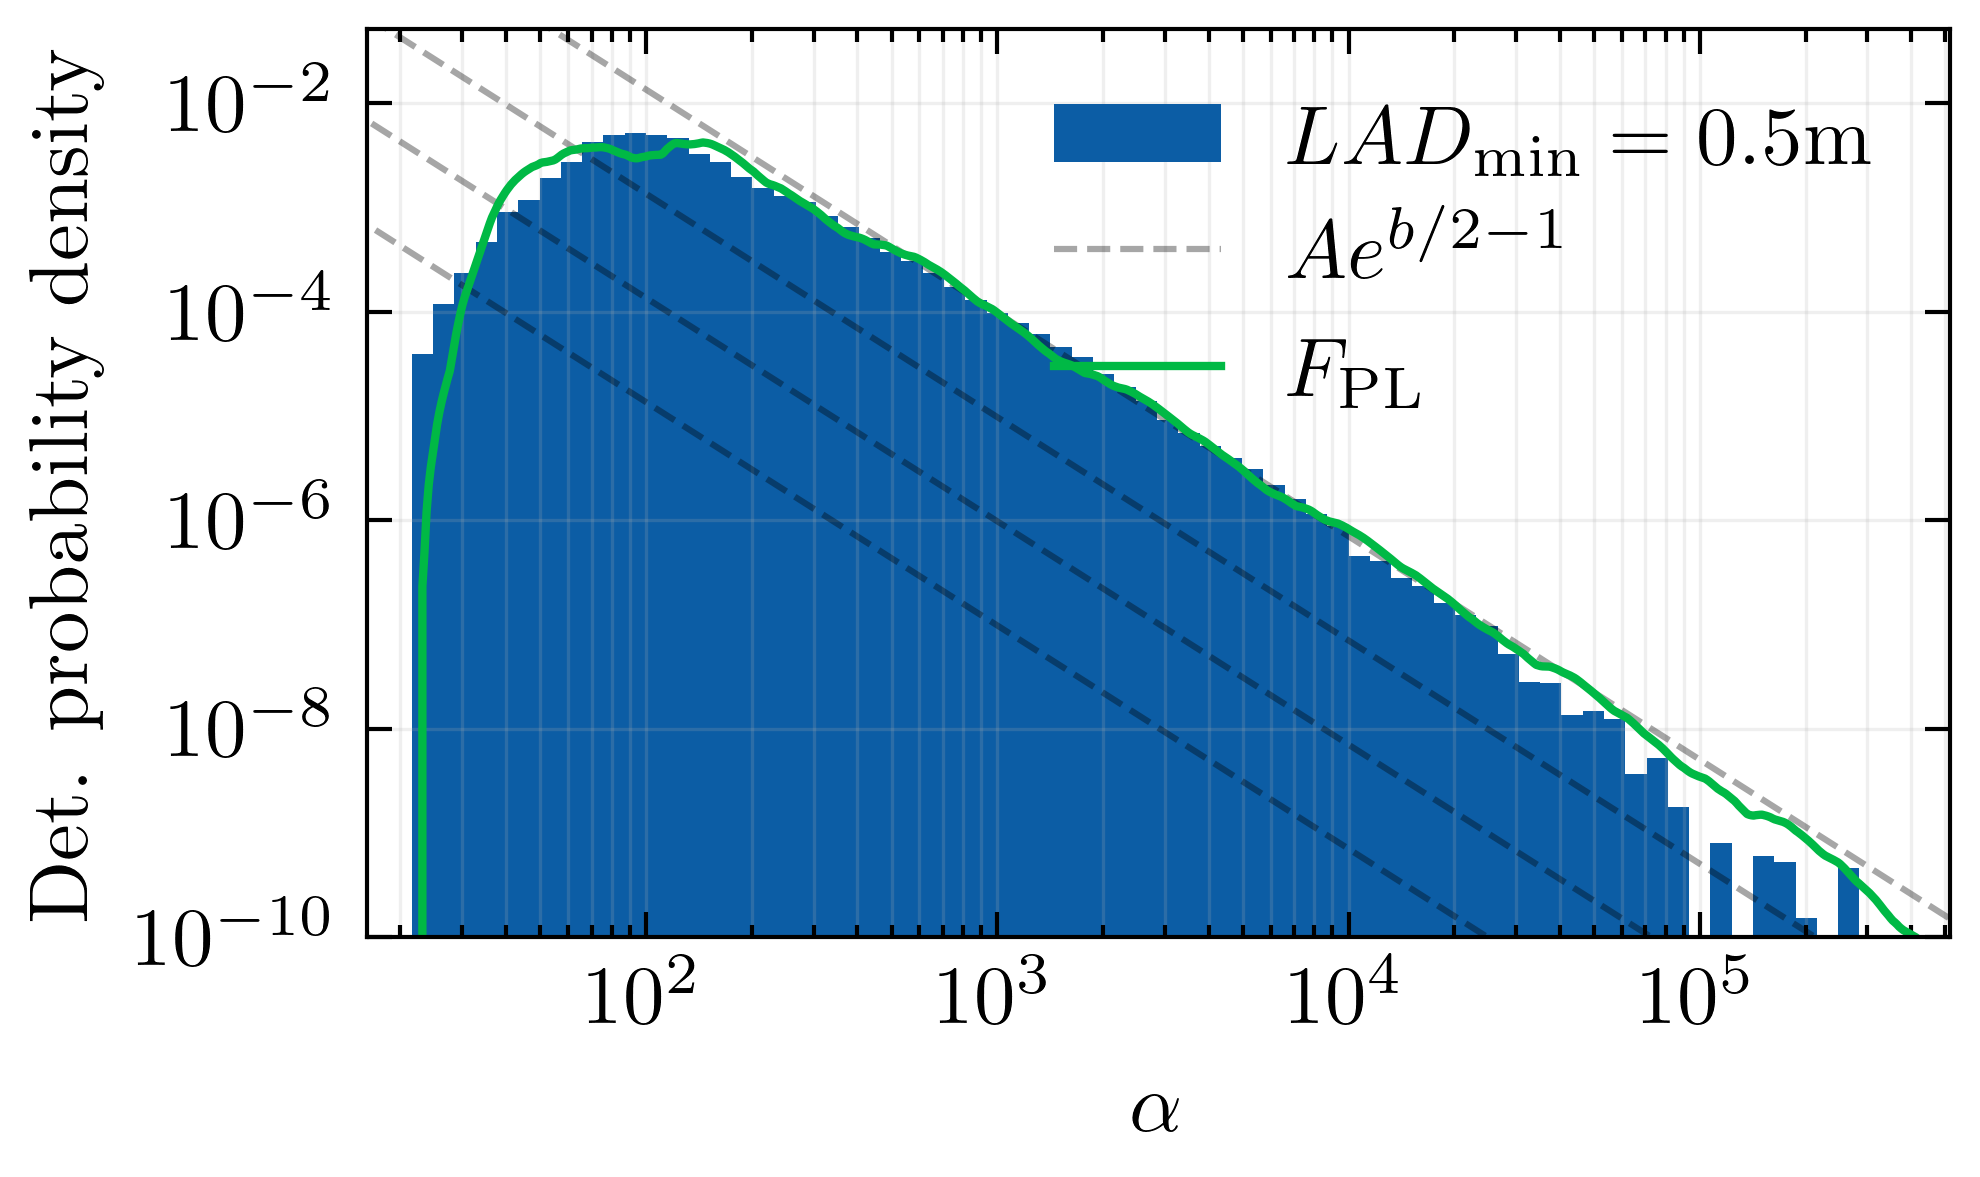

In [9]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_alphas_best_S,
                           alphas_hist, density = True, label = rf"$LAD_{{\text{{min}}}} = {fit.LAD_min}$m")

fit_params = PowerLawVarGFitParams(*mle_model.params)
# fit_params = PowerLawVarGFitParams(q=1.3, alpha=7.8, beta=10.67)

b = mle_model.params[0]
exp = -b - 1

# Fitted curve
y_fit = fit.F_norm(alphas, fit_params, sm.best_S_function)

# Reference point (middle of the x-range)
i0 = len(alphas) // 2
x0 = alphas[i0]
y0 = y_fit[i0]

# Guide lines, evenly spaced in log-space
factors = 10.0 ** np.arange(-3, 1)

for i, f in enumerate(factors):
    a = (f * y0) / x0**exp
    plt.plot(
        alphas,
        a * alphas**exp,
        "k--",
        alpha=0.35,
        lw=0.75,
        label = "$Ae^{b/2 - 1}$" if i == 0 else None,
    )

plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_S_function), label = r"$F_{\text{PL}}$")

plt.ylim(1e-10, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * (1/0.7))
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.savefig(f".plots/PL_fit_min_LAD_nonzero.png")
plt.show()

In [10]:
from datetime import datetime
from joblib import Parallel, delayed
from numpy.random import uniform
from scipy import interpolate

def run_sample(LAD_min : float, output_dir : Path) -> None:
    fit = PowerLawVarGFitting(dp, LAD_min=LAD_min, sensitivity_model = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg))

    df = fit.MultiMLEFit(
        optimize_params=PowerLawVarGFitParams(q=1, g_mu=0.6, g_std = 0.1),
        numb_runs = 5,
        summary = False
    ).with_columns(
        pl.lit(LAD_min).alias("LAD_min")
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_path: Path = output_dir / f"{timestamp}.parquet"
    file_path.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(file_path)

    print(f"Saved {file_path}")
    
output_dir = Path("multi_LAD_min_fit_data")
while True:
    u = np.random.uniform(np.log(0.05), np.log(10), size=100)
    x = np.exp(u)

    Parallel(n_jobs=6, verbose=100)(delayed(run_sample)(sample, output_dir) for sample in x)
    

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  3.1min
[Parallel(n_jobs=6)]: Done   2 tasks      | elapsed:  3.2min
[Parallel(n_jobs=6)]: Done   3 tasks      | elapsed:  3.5min
[Parallel(n_jobs=6)]: Done   4 tasks      | elapsed:  3.6min
[Parallel(n_jobs=6)]: Done   5 tasks      | elapsed:  4.2min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.9min
[Parallel(n_jobs=6)]: Done   7 tasks      | elapsed:  6.3min
[Parallel(n_jobs=6)]: Done   8 tasks      | elapsed:  6.4min
[Parallel(n_jobs=6)]: Done   9 tasks      | elapsed:  7.4min


c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[Parallel(n_jobs=6)]: Done  10 tasks      | elapsed:  9.0min
[Parallel(n_jobs=6)]: Done  11 tasks      | elapsed: 10.7min
[Parallel(n_jobs=6)]: Done  12 tasks      | elapsed: 10.9min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 11.7min
[Parallel(n_jobs=6)]: Done  14 tasks      | elapsed: 12.3min
[Parallel(n_jobs=6)]: Done  15 tasks      | elapsed: 14.0min
[Parallel(n_jobs=6)]: Done  16 tasks      | elapsed: 14.3min
[Parallel(n_jobs=6)]: Done  17 tasks      | elapsed: 14.5min
[Parallel(n_jobs=6)]: Done  18 tasks      | elapsed: 15.9min
[Parallel(n_jobs=6)]: Done  19 tasks      | elapsed: 16.2min
[Parallel(n_jobs=6)]: Done  20 tasks      | elapsed: 16.6min
[Parallel(n_jobs=6)]: Done  21 tasks      | elapsed: 17.2min
[Parallel(n_jobs=6)]: Done  22 tasks      | elapsed: 17.5min
[Parallel(n_jobs=6)]: Done  23 tasks      | elapsed: 18.6min


KeyboardInterrupt: 